In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_excel('visa_status_dataset.xlsx')

In [4]:
df.head()

,application_date,decision_date,visa_status,nationality,processing_center,applicant_age,gender,application_id
0,2019-11-27,2020-08-12,Approved,NaN,Dublin,NaN,Other,781436
1,2024-02-04,2024-07-24,NaN,Nigeria,NaN,30.0,Other,904539
2,2019-08-19,2021-10-15,Refused,Nigeria,Sydney,45.0,Other,114944
3,2020-12-29,2022-08-12,Pending,NaN,Dublin,45.0,Female,414037
4,2022-02-13,2024-04-24,Administrative Processing,Nigeria,New Delhi,60.0,Other,321361


In [5]:
from datetime import datetime

In [6]:
df['application_date']=pd.to_datetime(df['application_date'])
df['decision_date']=pd.to_datetime(df['decision_date'])

In [7]:
df['processing_days']=(df['decision_date']-df['application_date']).dt.days

In [8]:
df.isnull().sum()

application_date        0
decision_date           0
visa_status          6548
nationality          5428
processing_center    5473
applicant_age        5549
gender               8224
application_id          0
processing_days         0
dtype: int64

In [9]:
# Filling Missing Values

df['visa_status'].fillna('unknown', inplace=True)
df['nationality'].fillna('unknown',inplace=True)
df['processing_center'].fillna('unknown',inplace=True)
df['applicant_age']=df['applicant_age'].fillna(df['applicant_age'].mean()).round().astype(int)
df['gender'].fillna(df['gender'].mode()[0],inplace=True)

In [10]:
df.head()

,application_date,decision_date,visa_status,nationality,processing_center,applicant_age,gender,application_id,processing_days
0,2019-11-27,2020-08-12,Approved,unknown,Dublin,35,Other,781436,259
1,2024-02-04,2024-07-24,unknown,Nigeria,unknown,30,Other,904539,171
2,2019-08-19,2021-10-15,Refused,Nigeria,Sydney,45,Other,114944,788
3,2020-12-29,2022-08-12,Pending,unknown,Dublin,45,Female,414037,591
4,2022-02-13,2024-04-24,Administrative Processing,Nigeria,New Delhi,60,Other,321361,801


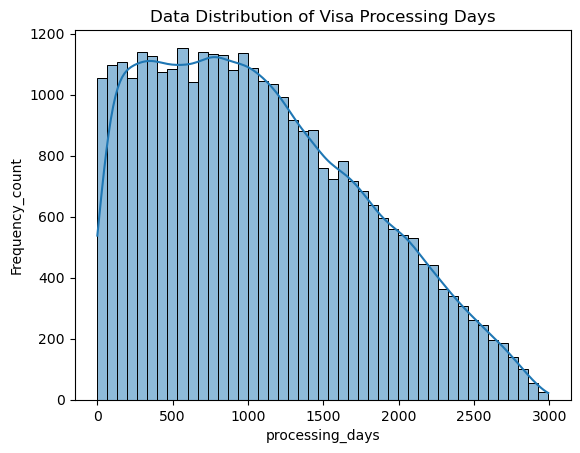

In [11]:
sns.histplot(df['processing_days'],kde=True)
plt.title('Data Distribution of Visa Processing Days')
plt.xlabel('processing_days')
plt.ylabel('Frequency_count')
plt.show()

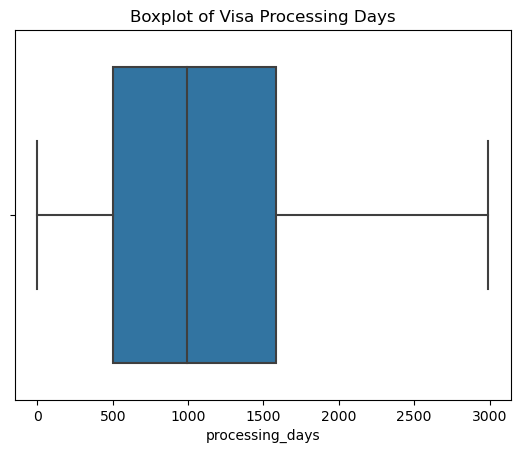

In [12]:
sns.boxplot(df['processing_days'])
plt.title('Boxplot of Visa Processing Days')
plt.show()

In [13]:
df['application_month']=df['application_date'].dt.month
df.head()

,application_date,decision_date,visa_status,nationality,processing_center,applicant_age,gender,application_id,processing_days,application_month
0,2019-11-27,2020-08-12,Approved,unknown,Dublin,35,Other,781436,259,11
1,2024-02-04,2024-07-24,unknown,Nigeria,unknown,30,Other,904539,171,2
2,2019-08-19,2021-10-15,Refused,Nigeria,Sydney,45,Other,114944,788,8
3,2020-12-29,2022-08-12,Pending,unknown,Dublin,45,Female,414037,591,12
4,2022-02-13,2024-04-24,Administrative Processing,Nigeria,New Delhi,60,Other,321361,801,2


In [14]:
corr_mat=df[['processing_days','application_month']].corr()
print(corr_mat)

                   processing_days  application_month
processing_days           1.000000          -0.034078
application_month        -0.034078           1.000000


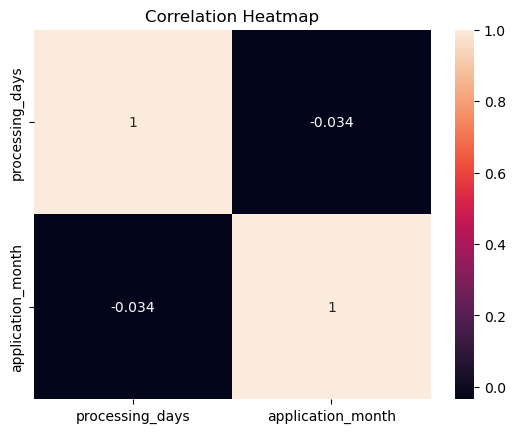

In [15]:
sns.heatmap(corr_mat,annot=True)
plt.title('Correlation Heatmap')
plt.show()

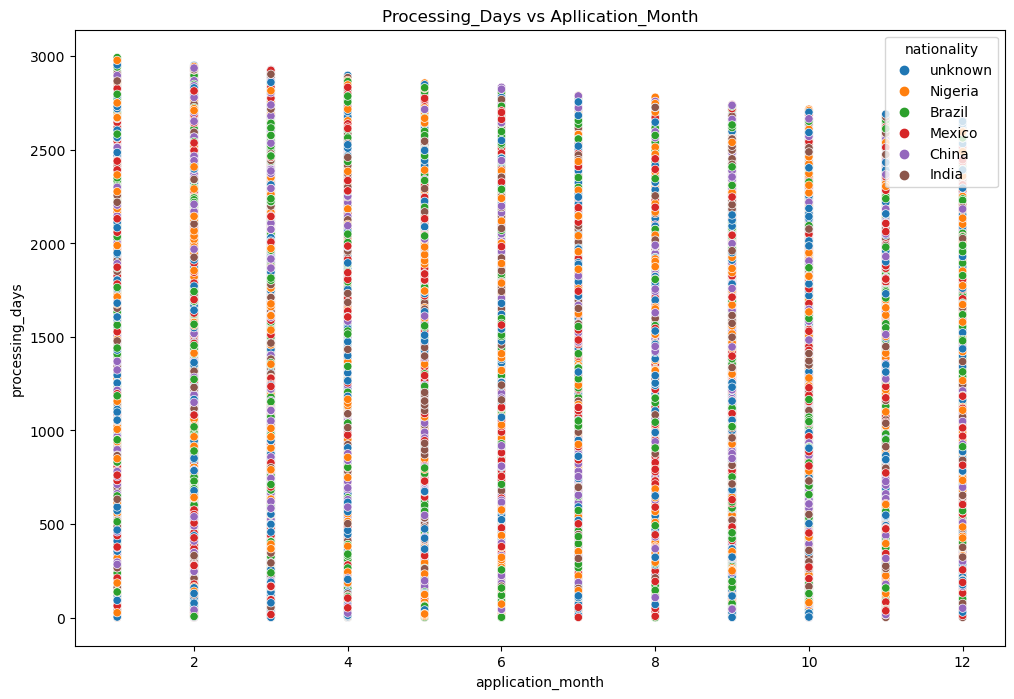

In [30]:
plt.figure(figsize=(12,8))
sns.scatterplot(df['application_month'],df['processing_days'],hue=df['nationality'])
plt.title('Processing_Days vs Apllication_Month')
plt.show()

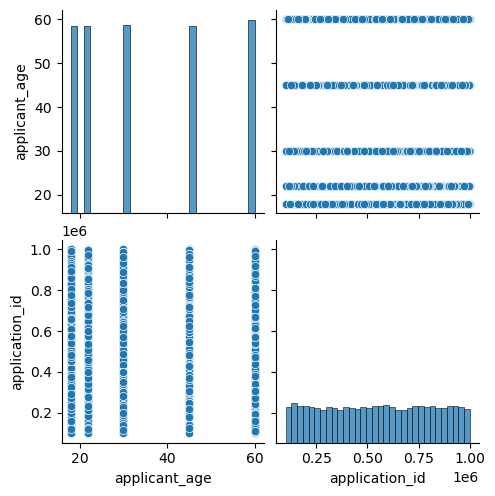

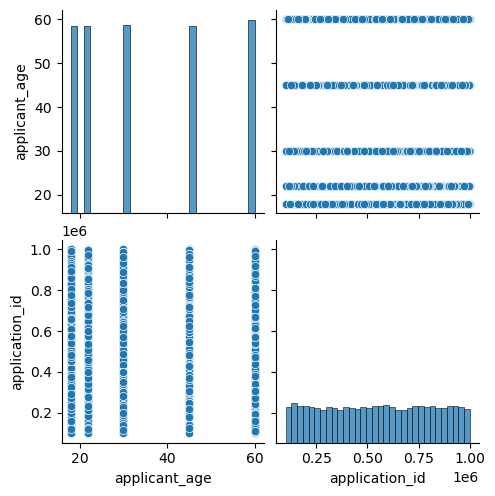

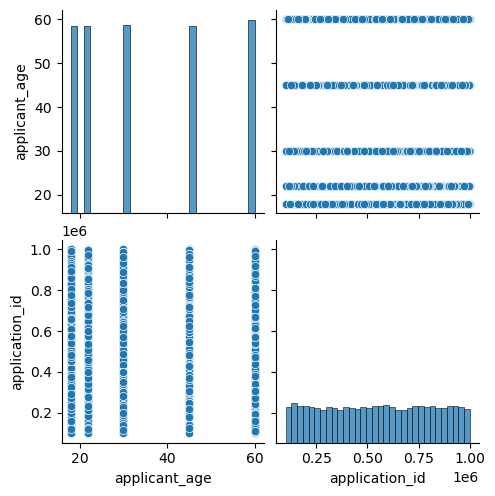

In [7]:
sns.pairplot(df)
plt.show()

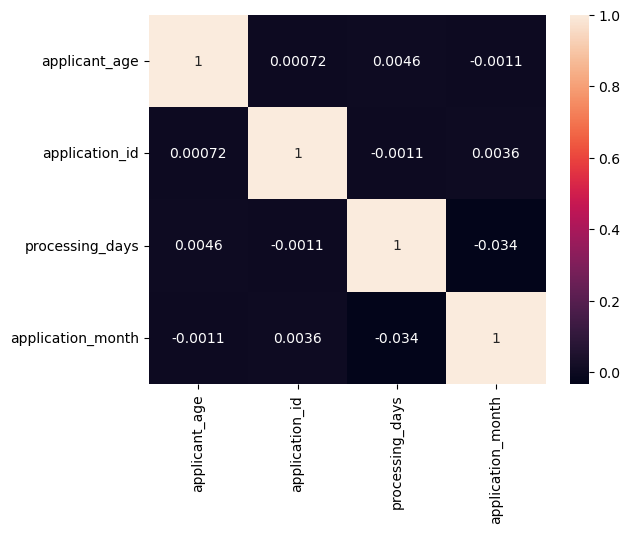

In [18]:
sns.heatmap(df.corr(),annot=True)
plt.show()

FEATURE ENGINEERING

In [16]:
# Feature 1
# Application Month

df[['application_date','application_month']].head()


,application_date,application_month
0,2019-11-27,11
1,2024-02-04,2
2,2019-08-19,8
3,2020-12-29,12
4,2022-02-13,2


In [17]:
# Feature 2
# Seasonal Index

df['season']=df['application_month'].apply(lambda x : 'Peak' if x in [1,2,12] else 'Off-Peak')
df[['application_month','season']].head()

,application_month,season
0,11,Off-Peak
1,2,Peak
2,8,Off-Peak
3,12,Peak
4,2,Peak


In [18]:
# Feature 3
# Country-Specific Average Processing Days

country_avg=df.groupby('nationality')['processing_days'].mean().round()
df['country_avg']=df['nationality'].map(country_avg)
df.head()

,application_date,decision_date,visa_status,nationality,processing_center,applicant_age,gender,application_id,processing_days,application_month,season,country_avg
0,2019-11-27,2020-08-12,Approved,unknown,Dublin,35,Other,781436,259,11,Off-Peak,1077.0
1,2024-02-04,2024-07-24,unknown,Nigeria,unknown,30,Other,904539,171,2,Peak,1074.0
2,2019-08-19,2021-10-15,Refused,Nigeria,Sydney,45,Other,114944,788,8,Off-Peak,1074.0
3,2020-12-29,2022-08-12,Pending,unknown,Dublin,45,Female,414037,591,12,Peak,1077.0
4,2022-02-13,2024-04-24,Administrative Processing,Nigeria,New Delhi,60,Other,321361,801,2,Peak,1074.0


In [19]:
# Feature 4
# Visa-Status Average Processing Time
visa_avg= df.groupby('visa_status')['processing_days'].mean().round()
df['visa_avg']=df['visa_status'].map(visa_avg)
df.head()

,application_date,decision_date,visa_status,nationality,processing_center,applicant_age,gender,application_id,processing_days,application_month,season,country_avg,visa_avg
0,2019-11-27,2020-08-12,Approved,unknown,Dublin,35,Other,781436,259,11,Off-Peak,1077.0,1095.0
1,2024-02-04,2024-07-24,unknown,Nigeria,unknown,30,Other,904539,171,2,Peak,1074.0,1081.0
2,2019-08-19,2021-10-15,Refused,Nigeria,Sydney,45,Other,114944,788,8,Off-Peak,1074.0,1062.0
3,2020-12-29,2022-08-12,Pending,unknown,Dublin,45,Female,414037,591,12,Peak,1077.0,1085.0
4,2022-02-13,2024-04-24,Administrative Processing,Nigeria,New Delhi,60,Other,321361,801,2,Peak,1074.0,1083.0


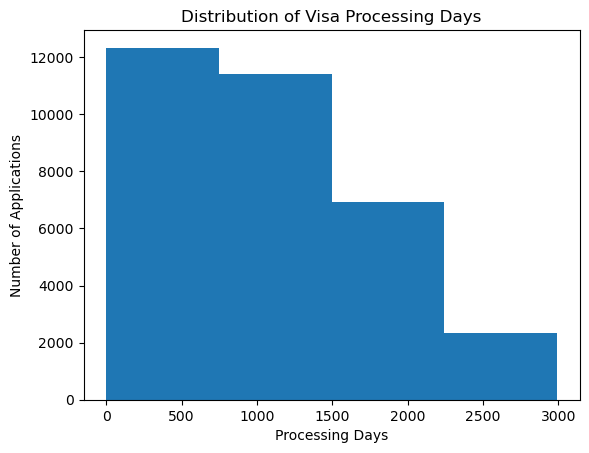

In [20]:
plt.hist(df['processing_days'],bins=4)
plt.title("Distribution of Visa Processing Days")
plt.xlabel("Processing Days")
plt.ylabel("Number of Applications")
plt.show()

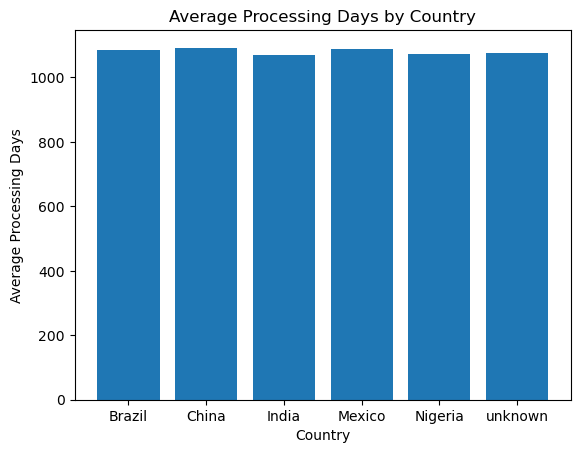

In [22]:
country_avg = df.groupby('nationality')["processing_days"].mean()

plt.figure()
plt.bar(country_avg.index, country_avg.values)

plt.title("Average Processing Days by Country")
plt.xlabel("Country")
plt.ylabel("Average Processing Days")

plt.show()

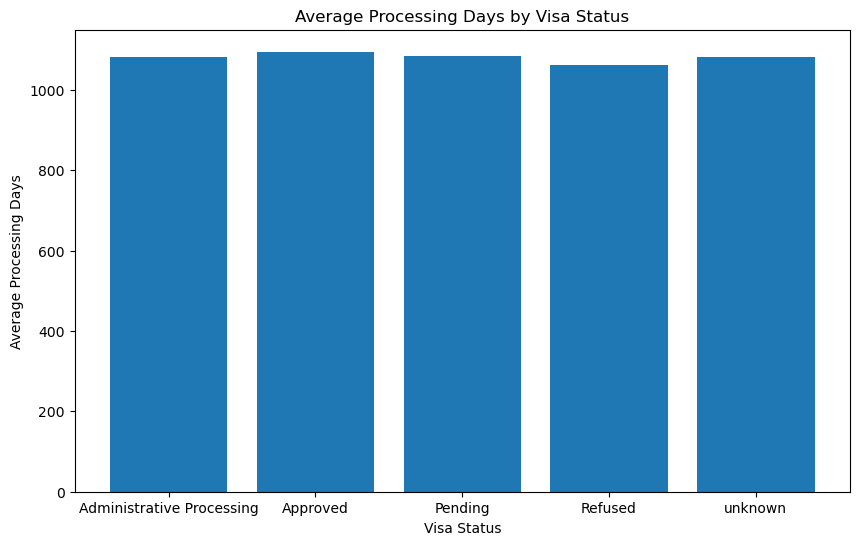

In [25]:
visa_avg = df.groupby("visa_status")["processing_days"].mean()

plt.figure(figsize=(10,6))
plt.bar(visa_avg.index, visa_avg.values)

plt.title("Average Processing Days by Visa Status")
plt.xlabel("Visa Status")
plt.ylabel("Average Processing Days")

plt.show()

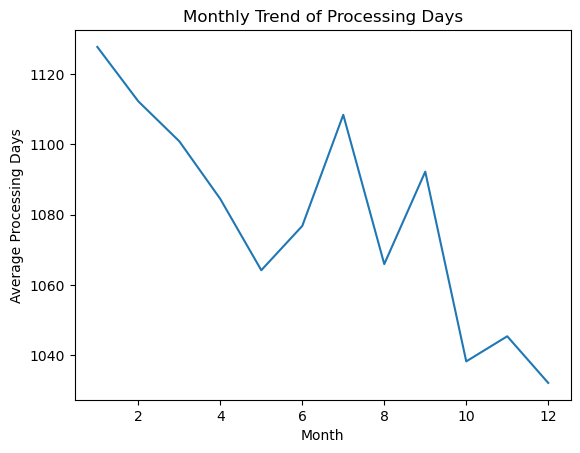

In [26]:
monthly_avg = df.groupby("application_month")["processing_days"].mean()

plt.figure()
plt.plot(monthly_avg.index, monthly_avg.values)

plt.title("Monthly Trend of Processing Days")
plt.xlabel("Month")
plt.ylabel("Average Processing Days")

plt.show()
